In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns
import json

In [2]:
# 1. Load the DataFrames
race_data = pd.read_csv("race_data.csv")
drop_data = pd.read_csv("drop_data.csv")

# Ensure Datetime is a proper datetime object
drop_data['Datetime'] = pd.to_datetime(drop_data['Datetime'])

# 2. Load the Dictionaries
with open("mapping_dicts.json", "r") as f:
    mappings = json.load(f)

race_to_id = mappings["race_to_id"]
batch_to_id = mappings["batch_to_id"]

# JSON saves dictionary keys as strings. We need to convert them back to integers
id_to_race = {int(k): v for k, v in mappings["id_to_race"].items()}
id_to_batch = {int(k): v for k, v in mappings["id_to_batch"].items()}

print("Data and Dictionaries loaded successfully!")
print(f"Number of tracking races: {len(id_to_race)}")

Data and Dictionaries loaded successfully!
Number of tracking races: 13


In [3]:
model_data = drop_data.dropna(subset=['this_batch_dem_proportion']).copy()
race_idx = model_data['race_id'].values 
n_races = len(race_data)
b_rt_observed = model_data['this_batch_dem_proportion'].values
baseline = model_data['baseline_dem_proportion'].values

In [4]:
with pm.Model() as election_model_v1:
    
    # 1. Hyperparameters
    # Variance between races
    sigma_r = pm.HalfNormal('sigma_r', sigma=0.05)     
    
    # The global shift parameters
    mu_g = pm.Normal('mu_g', mu=0.0, sigma=0.05)      
    sigma_g = pm.HalfNormal('sigma_g', sigma=0.05)    
    
    # Observation noise for a single batch drop
    sigma_batch = pm.HalfNormal('sigma_batch', sigma=0.05)

    # 2. Race-Specific Latent State (Non-centered parameterization)
    z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
    
    # s_r is now just the race's specific deviation from the global trend
    s_r = pm.Deterministic('s_r', z_r * sigma_r) 
    
    # 3. Global Latent State (Non-centered parameterization)
    z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
    s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

    # 4. Observation Layer 
    # Calculate the expected dem proportion for this specific batch drop
    # using the new perfectly mapped variables
    expected_b = s_r[race_idx] + s_g + baseline
    
    # The likelihood of the data we actually observed
    b_rt = pm.Normal('b_rt', 
                     mu=expected_b, 
                     sigma=sigma_batch, 
                     observed=b_rt_observed)

In [5]:
with election_model_v1:
    # Run the MCMC sampler
    trace_v1 = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.99, random_seed=42)
    
# Check out the summary of the latent parameters we care about
display(az.summary(trace_v1, var_names=['s_g', 's_r']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, mu_g, sigma_g, sigma_batch, z_r, z_g]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 30 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
s_g,0.006,0.014,-0.021,0.031,0.0,0.0,1931.0,2563.0,1.0
s_r[0],0.017,0.019,-0.021,0.053,0.0,0.0,3323.0,4357.0,1.0
s_r[1],0.012,0.019,-0.025,0.047,0.0,0.0,3300.0,4387.0,1.0
s_r[2],-0.019,0.021,-0.058,0.020,0.0,0.0,3798.0,4905.0,1.0
s_r[3],0.001,0.020,-0.036,0.038,0.0,0.0,3414.0,4477.0,1.0
s_r[4],0.027,0.019,-0.007,0.063,0.0,0.0,3038.0,4488.0,1.0
s_r[5],-0.031,0.020,-0.069,0.005,0.0,0.0,3344.0,4778.0,1.0
s_r[6],0.061,0.019,0.025,0.097,0.0,0.0,3470.0,4630.0,1.0
s_r[7],0.040,0.019,0.003,0.076,0.0,0.0,3327.0,4339.0,1.0
s_r[8],-0.032,0.019,-0.070,0.003,0.0,0.0,3309.0,4896.0,1.0


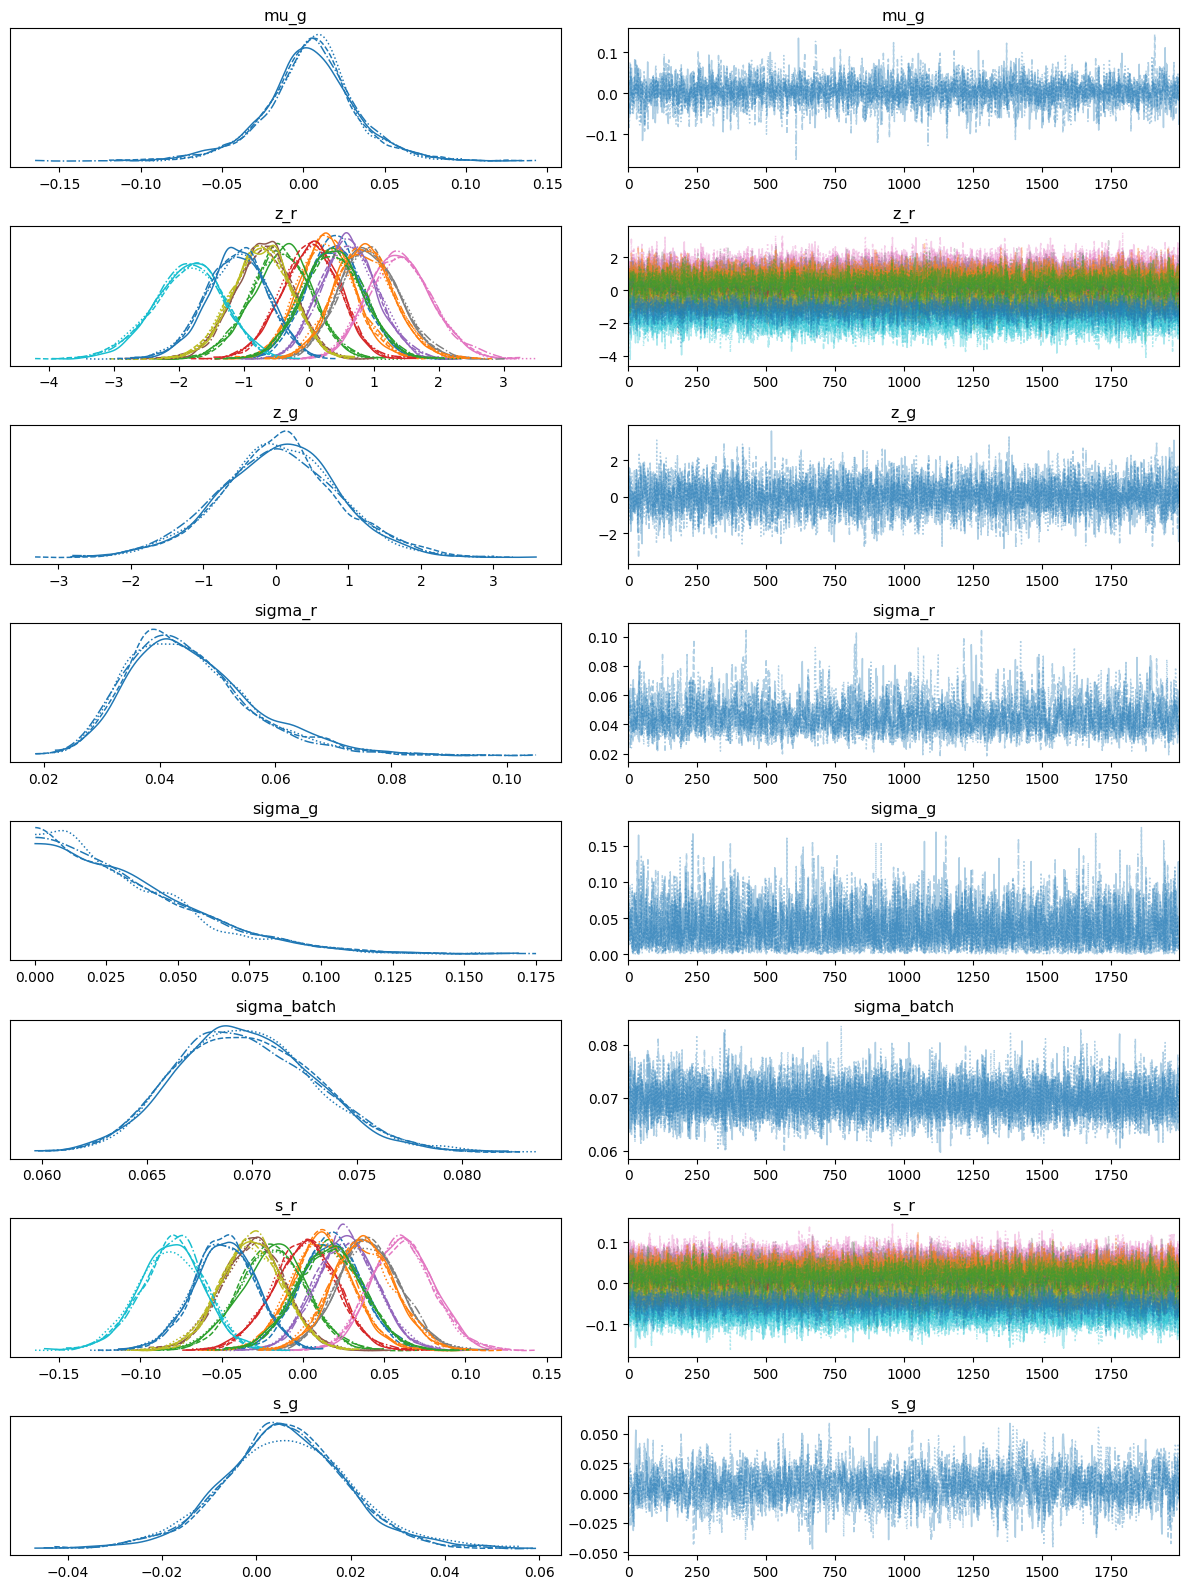

In [6]:
az.plot_trace(trace_v1)
plt.tight_layout()
plt.show()

In [ ]:
# Dictionary to store the traces for each batch
model_traces = {}

# Get a sorted list of all unique batch IDs in our filtered data
batches = sorted(model_data['batch_id'].unique())

for current_batch in batches:
    print(f"--- Training model up to batch_id: {current_batch} ---")
    
    # 1. Filter data cumulatively up to the current batch
    cumulative_drops = model_data[model_data['batch_id'] <= current_batch]
    
    # 2. Prepare PyMC inputs as numpy arrays for this specific iteration
    obs_race_idx = cumulative_drops['race_id'].values
    obs_b_rt = cumulative_drops['this_batch_dem_proportion'].values
    obs_baseline = cumulative_drops['baseline_dem_proportion'].values
    
    with pm.Model() as election_model_v1_seq:
        
        # Hyperparameters
        sigma_r = pm.HalfNormal('sigma_r', sigma=0.05)     
        mu_g = pm.Normal('mu_g', mu=0.0, sigma=0.05)      
        sigma_g = pm.HalfNormal('sigma_g', sigma=0.05)    
        sigma_batch = pm.HalfNormal('sigma_batch', sigma=0.05)

        # Race-Specific Latent State (Non-centered)
        z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
        s_r = pm.Deterministic('s_r', z_r * sigma_r) 
        
        # Global Latent State (Non-centered)
        z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
        s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

        # Observation Layer 
        expected_b = s_r[obs_race_idx] + s_g + obs_baseline
        
        b_rt = pm.Normal('b_rt', 
                         mu=expected_b, 
                         sigma=sigma_batch, 
                         observed=obs_b_rt)
        
        # Sample the posterior
        # progressbar=False keeps the terminal output clean since we are in a loop
        trace = pm.sample(
            draws=2000, 
            tune=1000, 
            chains=4, 
            cores=4, 
            target_accept=0.99, 
            progressbar=True,
            random_seed=42
        )
        
    # Store the trace keyed by the batch ID
    model_traces[current_batch] = trace

print("Sequential training complete! Traces are stored in the 'model_traces' dictionary.")

In [8]:
print("--- Model Diagnostics (Convergence Check) ---")

# We exclude the 'z_r' and 'z_g' raw values, focusing on the core parameters
check_vars = ["mu_g", "sigma_g", "sigma_r", "sigma_batch", "s_g"]

for batch in batches:
    tmp = az.summary(model_traces[batch], var_names=check_vars)
    
    min_ess_bulk = tmp['ess_bulk'].min()
    min_ess_tail = tmp['ess_tail'].min()
    max_r_hat = tmp['r_hat'].max()
    
    print(f"Batch {batch:2} | max r_hat: {max_r_hat:.3f} | min ess_bulk: {min_ess_bulk:4.0f} | min ess_tail: {min_ess_tail:4.0f}")

print("\nIf all r_hats are near 1.0, the model sampled perfectly!")

--- Model Diagnostics (Convergence Check) ---
Batch  0 | max r_hat: 1.010 | min ess_bulk:  437 | min ess_tail:  437
Batch  1 | max r_hat: 1.000 | min ess_bulk: 3071 | min ess_tail: 3408
Batch  2 | max r_hat: 1.000 | min ess_bulk: 2222 | min ess_tail: 2165
Batch  3 | max r_hat: 1.000 | min ess_bulk: 1828 | min ess_tail: 1574
Batch  4 | max r_hat: 1.000 | min ess_bulk: 1940 | min ess_tail: 1698
Batch  5 | max r_hat: 1.000 | min ess_bulk: 2130 | min ess_tail: 1656
Batch  6 | max r_hat: 1.000 | min ess_bulk: 1971 | min ess_tail: 1634
Batch  7 | max r_hat: 1.000 | min ess_bulk: 2338 | min ess_tail: 3050
Batch  8 | max r_hat: 1.000 | min ess_bulk: 2212 | min ess_tail: 3446
Batch  9 | max r_hat: 1.000 | min ess_bulk: 2395 | min ess_tail: 3161
Batch 10 | max r_hat: 1.000 | min ess_bulk: 2086 | min ess_tail: 2950
Batch 11 | max r_hat: 1.000 | min ess_bulk: 2065 | min ess_tail: 2387
Batch 12 | max r_hat: 1.000 | min ess_bulk: 2269 | min ess_tail: 3078
Batch 13 | max r_hat: 1.000 | min ess_bulk: 

In [11]:
import os

# Create directory if it doesn't exist
os.makedirs("v1_traces", exist_ok=True)

print("Saving traces...")

for current_batch in batches:
    file_path = f"v1_traces/trace_batch_{current_batch}.nc"
    
    # Check if the file already exists to explicitly note we are overwriting
    if os.path.exists(file_path):
        os.remove(file_path) # Safely remove the old one first just in case
        
    model_traces[current_batch].to_netcdf(file_path)
    print(f"Saved: {file_path}")

print("All traces successfully saved!")

Saving traces...
Saved: v1_traces/trace_batch_0.nc
Saved: v1_traces/trace_batch_1.nc
Saved: v1_traces/trace_batch_2.nc
Saved: v1_traces/trace_batch_3.nc
Saved: v1_traces/trace_batch_4.nc
Saved: v1_traces/trace_batch_5.nc
Saved: v1_traces/trace_batch_6.nc
Saved: v1_traces/trace_batch_7.nc
Saved: v1_traces/trace_batch_8.nc
Saved: v1_traces/trace_batch_9.nc
Saved: v1_traces/trace_batch_10.nc
Saved: v1_traces/trace_batch_11.nc
Saved: v1_traces/trace_batch_12.nc
Saved: v1_traces/trace_batch_13.nc
Saved: v1_traces/trace_batch_14.nc
Saved: v1_traces/trace_batch_15.nc
Saved: v1_traces/trace_batch_16.nc
Saved: v1_traces/trace_batch_17.nc
Saved: v1_traces/trace_batch_18.nc
Saved: v1_traces/trace_batch_19.nc
Saved: v1_traces/trace_batch_20.nc
Saved: v1_traces/trace_batch_21.nc
Saved: v1_traces/trace_batch_22.nc
Saved: v1_traces/trace_batch_23.nc
All traces successfully saved!


In [14]:
# Create an array of baselines aligned 0-12 to perfectly match the s_r columns
baseline_array = race_data.sort_values('race_id')['baseline_dem_proportion'].values

extracted_posteriors = {}

for current_batch, trace in model_traces.items():
    
    # 1. Extract the raw multi-dimensional arrays
    s_r_raw = trace.posterior["s_r"].values               # Shape: (chains, draws, n_races)
    s_g_raw = trace.posterior["s_g"].values               # Shape: (chains, draws)
    sig_batch_raw = trace.posterior["sigma_batch"].values # Shape: (chains, draws)
    
    # 2. Flatten the chains and draws together into one long sequence
    s_r_flat = s_r_raw.reshape(-1, s_r_raw.shape[-1]) # Shape: (total_samples, n_races)
    s_g_flat = s_g_raw.flatten()                      # Shape: (total_samples,)
    sig_batch_flat = sig_batch_raw.flatten()          # Shape: (total_samples,)
    
    # 3. Calculate the step size to get exactly 1000 draws
    total_samples = len(s_g_flat)
    step = total_samples // 1000
    
    # 4. Slice the arrays evenly and cap at exactly 1000 (just in case of weird math)
    s_r_1000 = s_r_flat[::step][:1000]
    s_g_1000 = s_g_flat[::step][:1000]
    sig_batch_1000 = sig_batch_flat[::step][:1000]
    
    # 5. Calculate the expected Dem Prop for ALL races
    expected_b_1000 = s_r_1000 + s_g_1000[:, np.newaxis] + baseline_array
    
    # Store the parameters
    extracted_posteriors[current_batch] = {
        "expected_b": expected_b_1000,   # Shape: (1000, n_races)
        "sigma_batch": sig_batch_1000    # Shape: (1000,)
    }

print("Evenly spaced posterior draws extracted and stored in 'extracted_posteriors'.")

Evenly spaced posterior draws extracted and stored in 'extracted_posteriors'.


In [15]:
# Use NumPy's random generator (seed for reproducibility)
rng = np.random.default_rng(seed=42)

simulated_future_batches = {}
total_batches = len(batches)

print("Simulating remaining batches...")

# Iterate through every batch step
for i, current_batch in enumerate(batches):
    
    # How many actual batches are left to simulate?
    n_remaining = total_batches - i - 1
    
    if n_remaining > 0:
        # 1. Grab the expected parameters for this specific timestamp
        # exp_b_1000 shape: (1000, n_races)
        # sig_batch_1000 shape: (1000,)
        exp_b_1000 = extracted_posteriors[current_batch]['expected_b']
        sig_batch_1000 = extracted_posteriors[current_batch]['sigma_batch']
        
        n_races = exp_b_1000.shape[1]
        
        # 2. Reshape to add a "remaining batches" dimension in the middle
        # Shape becomes (1000, 1, n_races)
        exp_b_reshaped = exp_b_1000[:, np.newaxis, :]
        
        # Shape becomes (1000, 1, 1)
        sig_batch_reshaped = sig_batch_1000[:, np.newaxis, np.newaxis]
        
        # 3. Draw the Monte Carlo samples!
        # Output shape: (1000, n_remaining, n_races)
        simulations = rng.normal(
            loc=exp_b_reshaped, 
            scale=sig_batch_reshaped, 
            size=(1000, n_remaining, n_races)
        )
        
        simulated_future_batches[current_batch] = simulations
        
    else:
        # For the final batch, there are 0 remaining batches, so no simulation needed
        simulated_future_batches[current_batch] = None

print("Future batch simulations complete. Stored in 'simulated_future_batches'.")

Simulating remaining batches...
Future batch simulations complete. Stored in 'simulated_future_batches'.


In [16]:
rng = np.random.default_rng(seed=42)
final_outcomes_dict = {}
concentration_scale = 20.0 

print("Projecting final totals for all batches...")

for i, current_batch in enumerate(batches):
    n_remaining = len(batches) - i - 1
    
    # --- THE CLEAN CARRY-FORWARD DATA PREP ---
    # 1. Filter all drops up to the current batch
    cumulative_data = model_data[model_data['batch_id'] <= current_batch]
    
    # 2. Get the latest known state for every race up to this exact moment
    current_data = cumulative_data.sort_values('batch_id').drop_duplicates(subset=['race_id'], keep='last')
    
    # 3. Initialize zero arrays for all 13 races
    current_dem_votes = np.zeros(n_races)
    votes_remaining = np.zeros(n_races)
    
    # 4. Map the latest values directly into the arrays using our 0-indexed race_id
    current_race_indices = current_data['race_id'].values
    
    # Grab the total Dem votes counted so far
    current_dem_votes[current_race_indices] = current_data['up_to_this_batch_dem_votes'].values
    
    # Calculate remaining votes dynamically! (Final Total - Counted So Far)
    calc_remaining = current_data['final_total_votes'] - current_data['up_to_this_batch_total_votes']
    
    # np.maximum(0, ...) ensures we never accidentally predict negative votes remaining
    votes_remaining[current_race_indices] = np.maximum(0, calc_remaining.values)
    # -------------------------------------------------------------------------
    
    if n_remaining > 0:
        # Build the logarithmic Dirichlet weights
        log_weights = np.log(1 + 1 / np.arange(1, n_remaining + 1))
        alphas = log_weights * concentration_scale
        
        # Draw Dirichlet proportions
        dirichlet_draws = rng.dirichlet(alpha=alphas, size=(1000, n_races))
        dirichlet_draws = dirichlet_draws.transpose(0, 2, 1)
        
        # Multiply proportions by votes_remaining 
        sim_batch_sizes = dirichlet_draws * votes_remaining
        
        # Extract Dem vote proportions (from our earlier MCMC simulation)
        sim_dem_rates = simulated_future_batches[current_batch]
        
        # Calculate added Dem votes for every future batch
        added_dem_votes_per_batch = sim_batch_sizes * sim_dem_rates
        
        # Sum up the added Dem votes across all remaining batches
        total_added_dem_votes = added_dem_votes_per_batch.sum(axis=1)
        
        # Add the newly counted votes to the votes the candidate ALREADY had
        final_simulated_dem_votes = current_dem_votes + total_added_dem_votes
        
        final_outcomes_dict[current_batch] = final_simulated_dem_votes

    else:
        # Final batch: Just tile the most recent current_dem_votes 1000 times
        final_outcomes_dict[current_batch] = np.tile(current_dem_votes, (1000, 1))

print("Projection complete! Simulated final Dem Vote counts stored in 'final_outcomes_dict'.")

Projecting final totals for all batches...
Projection complete! Simulated final Dem Vote counts stored in 'final_outcomes_dict'.


Plotting projections with bounds...


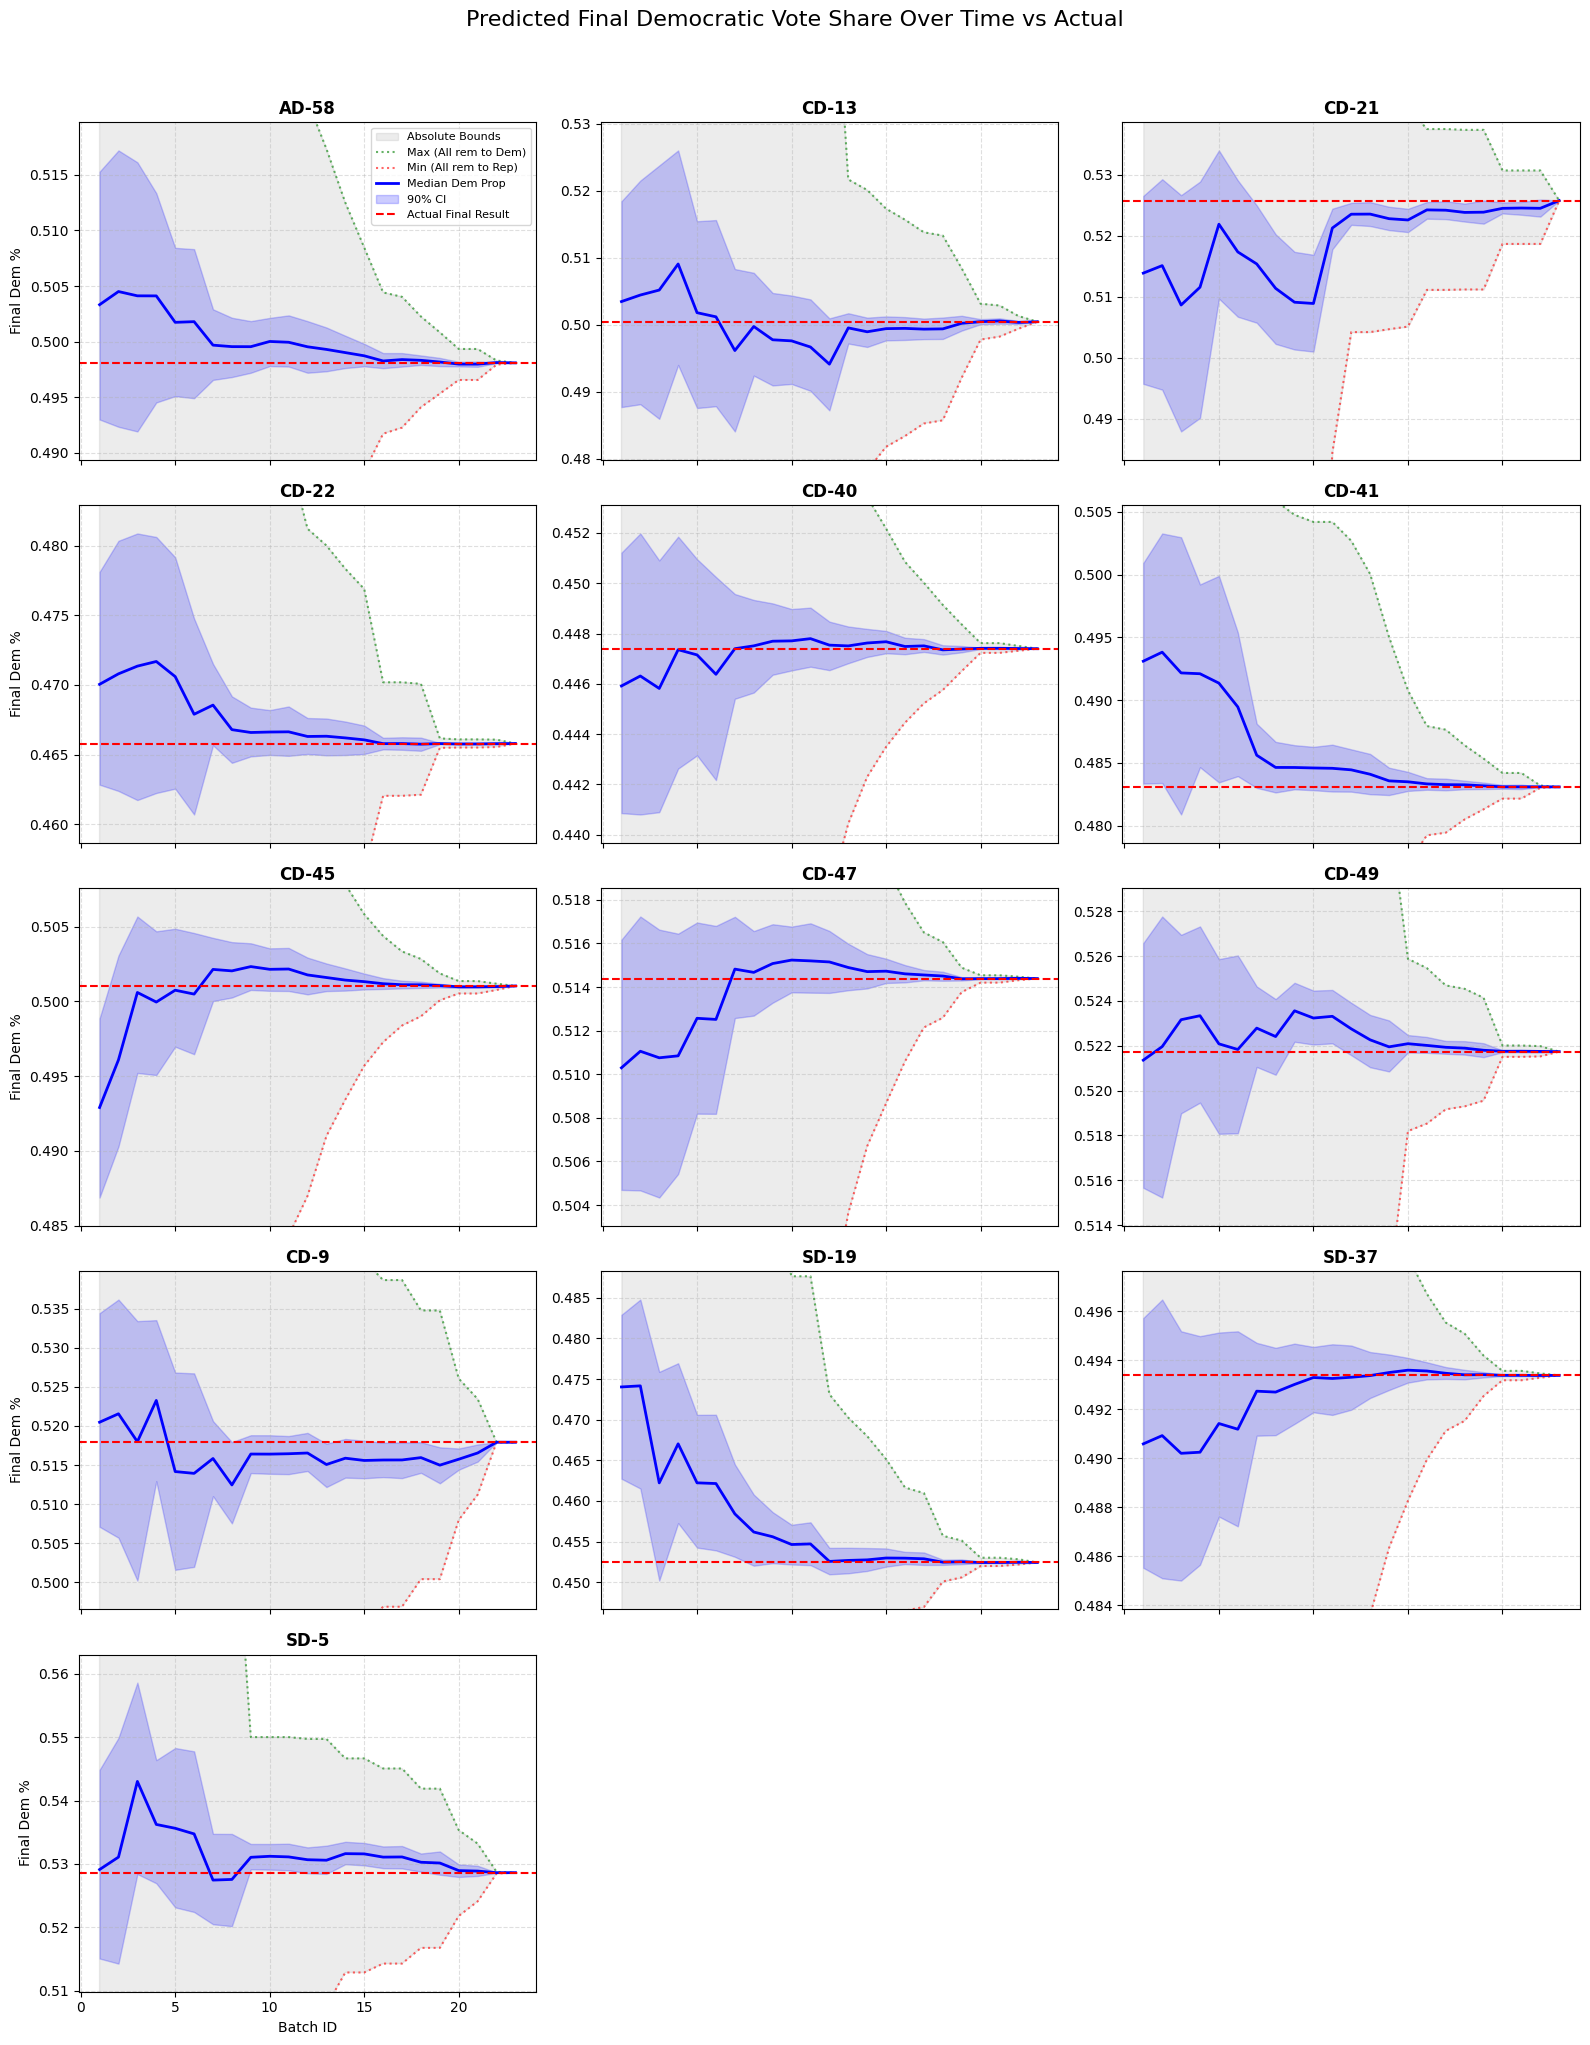

In [21]:
# 1. Variables
batch_list = list(final_outcomes_dict.keys())
race_denominators = race_data.sort_values('race_id')['final_total_votes'].values

# 2. Set up the plot grid
cols = 3
rows = int(np.ceil(n_races / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows), sharex=True)
axes = axes.flatten()

print("Plotting projections with bounds...")

for race_idx in range(n_races):
    ax = axes[race_idx]
    race_name = id_to_race[race_idx]
    
    race_denominator = race_denominators[race_idx]
    
    p05, p50, p95 = [], [], []
    min_bounds, max_bounds = [], []
    
    for b in batch_list:
        # Extract percentiles and convert to proportions
        sims_prop = final_outcomes_dict[b][:, race_idx] / race_denominator
        
        p05.append(np.percentile(sims_prop, 5))
        p50.append(np.percentile(sims_prop, 50))
        p95.append(np.percentile(sims_prop, 95))
        
        # --- NEW: Extract current data up to this batch to find absolute bounds ---
        cum_data = model_data[(model_data['batch_id'] <= b) & (model_data['race_id'] == race_idx)]
        
        if len(cum_data) > 0:
            current_dem = cum_data['up_to_this_batch_dem_votes'].iloc[-1]
            current_total = cum_data['up_to_this_batch_total_votes'].iloc[-1]
        else:
            # Fallback to the starting baseline if this race hasn't updated yet!
            baseline_data = race_data[race_data['race_id'] == race_idx]
            current_dem = baseline_data['baseline_dem_votes'].values[0]
            current_total = baseline_data['baseline_total_votes'].values[0]
            
        rem_votes = race_denominator - current_total
        
        # Min = Dem gets 0% of remaining, Max = Dem gets 100% of remaining
        min_bounds.append(current_dem / race_denominator)
        max_bounds.append((current_dem + rem_votes) / race_denominator)
        # -------------------------------------------------------------------------
        
    # Plotting Bounding Regions First
    ax.fill_between(batch_list[1:], min_bounds[1:], max_bounds[1:], color='gray', alpha=0.15, label='Absolute Bounds')
    ax.plot(batch_list[1:], max_bounds[1:], color='green', linestyle=':', alpha=0.6, label='Max (All rem to Dem)')
    ax.plot(batch_list[1:], min_bounds[1:], color='red', linestyle=':', alpha=0.6, label='Min (All rem to Rep)')

    # Plotting Simulations
    ax.plot(batch_list[1:], p50[1:], color='blue', linewidth=2, label='Median Dem Prop')
    ax.fill_between(batch_list[1:], p05[1:], p95[1:], color='blue', alpha=0.2, label='90% CI')
    
    # Plotting Actual Final Result
    actual_final_prop = race_data[race_data['race_id'] == race_idx]['final_dem_proportion'].values[0]
    ax.axhline(actual_final_prop, color='red', linestyle='--', label='Actual Final Result')
    
    # --- Y-axis Zoom logic based ONLY on the simulations & actual result ---
    sim_min = min(p05[1:])
    sim_max = max(p95[1:])
    
    # We include actual_final_prop so the red dashed line never gets cut off
    plot_min = min(sim_min, actual_final_prop)
    plot_max = max(sim_max, actual_final_prop)
    
    y_range = plot_max - plot_min
    padding = y_range * 0.1 if y_range > 0 else 0.05 
    
    ax.set_ylim(plot_min - padding, plot_max + padding)
    # -------------------------------------------------------------------------
    
    # Formatting
    ax.set_title(f"{race_name}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if race_idx % cols == 0:
        ax.set_ylabel("Final Dem %")
    if race_idx >= (rows - 1) * cols:
        ax.set_xlabel("Batch ID")

# Delete extra empty subplots
for i in range(n_races, len(axes)):
    fig.delaxes(axes[i])

# Legend on the first chart only
axes[0].legend(loc='best', fontsize=8)
plt.suptitle("Predicted Final Democratic Vote Share Over Time vs Actual", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# 1. We'll make a clean copy so we don't mess up our main dataframe
baseline_df = model_data.copy()

# 2. How many votes are remaining in the election at this exact batch step?
baseline_df['remaining_votes'] = np.maximum(0, baseline_df['final_total_votes'] - baseline_df['up_to_this_batch_total_votes'])

# 3. Project the final Dem Votes
# We assume the candidate keeps their current votes, and wins all REMAINING votes at the exact 
# same rate they've been winning post-election-night votes
baseline_df['simple_projected_dem_votes'] = (
    baseline_df['up_to_this_batch_dem_votes'] + 
    (baseline_df['remaining_votes'] * baseline_df['up_to_this_batch_no_baseline_dem_proportion'])
)

# 4. Convert projected votes to projected proportion
baseline_df['simple_prediction'] = baseline_df['simple_projected_dem_votes'] / baseline_df['final_total_votes']

# 5. Calculate Absolute Error AND Squared Error against the True Final Result
baseline_df['simple_abs_error'] = np.abs(baseline_df['simple_prediction'] - baseline_df['final_dem_proportion'])
baseline_df['simple_sq_error'] = (baseline_df['simple_prediction'] - baseline_df['final_dem_proportion']) ** 2

# 6. Forward Fill logic for races that don't update every batch
all_races = baseline_df['race_id'].unique()
all_batches = baseline_df['batch_id'].unique()
full_grid = pd.MultiIndex.from_product([all_races, all_batches], names=['race_id', 'batch_id'])

# Reindex and forward fill the missing states
df_full = baseline_df.set_index(['race_id', 'batch_id']).reindex(full_grid).reset_index()
df_full = df_full.sort_values(['race_id', 'batch_id'])

# Make sure to include both error columns in the forward fill!
df_full[['simple_prediction', 'simple_abs_error', 'simple_sq_error']] = df_full.groupby('race_id')[['simple_prediction', 'simple_abs_error', 'simple_sq_error']].ffill()

# Drop rows that are still NaN (meaning the race hasn't had its first update yet)
df_full = df_full.dropna(subset=['simple_abs_error'])

# 7. Calculate Mean Absolute Error (MAE) and Mean Squared Error (MSE) per batch
simple_error_summary = df_full.groupby('batch_id').agg(
    MAE_Simple=('simple_abs_error', 'mean'),
    MSE_Simple=('simple_sq_error', 'mean'),
    N_Races=('race_id', 'count')
).reset_index()

# 8. Calculate RMSE by taking the square root of the MSE
simple_error_summary['RMSE_Simple'] = np.sqrt(simple_error_summary['MSE_Simple'])

# Drop MSE as we usually just want to look at MAE and RMSE
simple_error_summary = simple_error_summary.drop(columns=['MSE_Simple'])

print("Simple Baseline Errors Calculated:")
display(simple_error_summary.head(10))

Simple Baseline Errors Calculated:


,batch_id,MAE_Simple,N_Races,RMSE_Simple
0,0,0.013657,12,0.019347
1,1,0.008471,13,0.012553
2,2,0.008303,13,0.012511
3,3,0.008403,13,0.012826
4,4,0.007850,13,0.011834
5,5,0.004783,13,0.005879
6,6,0.004194,13,0.005383
7,7,0.002457,13,0.003715
8,8,0.001827,13,0.002138
9,9,0.002213,13,0.002742


In [26]:
actual_final_props = race_data.sort_values('race_id')['final_dem_proportion'].values
race_denominators = race_data.sort_values('race_id')['final_total_votes'].values

mcmc_records = []

# 2. Loop through our simulated predictions
for batch_id in batches:
    # Get the 1000 simulations for this batch (Shape: 1000 simulations x 13 races)
    mcmc_sims = final_outcomes_dict[batch_id] 
    
    # Take the median projection for each race across the 1000 simulations
    mcmc_pred_votes = np.median(mcmc_sims, axis=0)
    
    # Convert raw votes to proportions
    mcmc_pred_prop = mcmc_pred_votes / race_denominators
    
    # Calculate Absolute and Squared Errors
    abs_errors = np.abs(mcmc_pred_prop - actual_final_props)
    sq_errors = (mcmc_pred_prop - actual_final_props) ** 2
    
    # Average the errors across all 13 races for this batch
    mcmc_records.append({
        'batch_id': batch_id,
        'MAE_MCMC': np.mean(abs_errors),
        'MSE_MCMC': np.mean(sq_errors)
    })

# 3. Build the dataframe and calculate RMSE
mcmc_error_summary = pd.DataFrame(mcmc_records)
mcmc_error_summary['RMSE_MCMC'] = np.sqrt(mcmc_error_summary['MSE_MCMC'])
mcmc_error_summary = mcmc_error_summary.drop(columns=['MSE_MCMC'])

# 4. Merge MCMC errors with the Simple Baseline errors we just calculated
plot_df = pd.merge(simple_error_summary, mcmc_error_summary, on='batch_id', how='inner')

# --- THE FIX: Drop batch 0 from the dataframe before plotting ---
plot_df = plot_df[plot_df['batch_id'] != 0].copy()

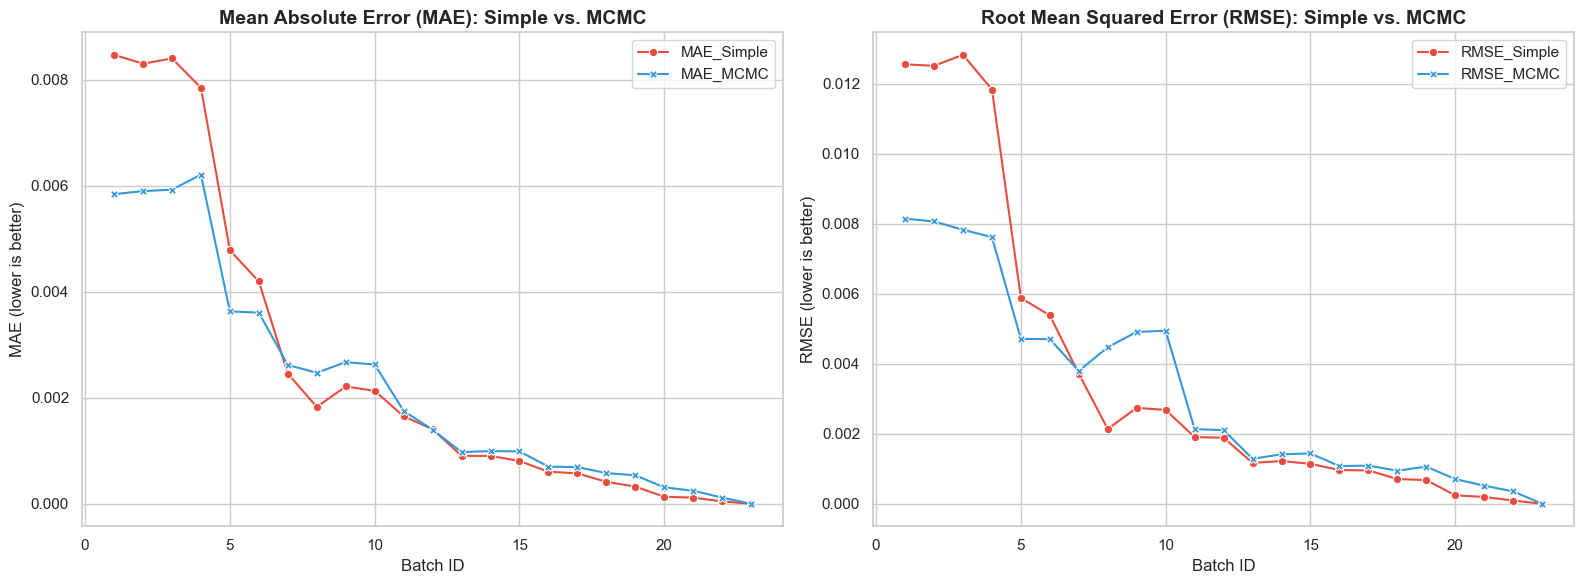

In [27]:
ig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- Plot 1: MAE ---
sns.lineplot(
    data=plot_df.set_index('batch_id')[['MAE_Simple', 'MAE_MCMC']], 
    markers=True, 
    dashes=False,
    ax=axes[0],
    palette=["#e74c3c", "#3498db"] # Red for Simple, Blue for MCMC
)
axes[0].set_title("Mean Absolute Error (MAE): Simple vs. MCMC", fontsize=14, fontweight='bold')
axes[0].set_ylabel("MAE (lower is better)", fontsize=12)
axes[0].set_xlabel("Batch ID", fontsize=12)

# --- Plot 2: RMSE ---
sns.lineplot(
    data=plot_df.set_index('batch_id')[['RMSE_Simple', 'RMSE_MCMC']], 
    markers=True, 
    dashes=False,
    ax=axes[1],
    palette=["#e74c3c", "#3498db"] 
)
axes[1].set_title("Root Mean Squared Error (RMSE): Simple vs. MCMC", fontsize=14, fontweight='bold')
axes[1].set_ylabel("RMSE (lower is better)", fontsize=12)
axes[1].set_xlabel("Batch ID", fontsize=12)

plt.tight_layout()
plt.show()